# Customer Segmentation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("../data/engineered/customers_engineered.csv")
orders = pd.read_csv("../data/engineered/orders_engineered.csv")
payments = pd.read_csv("../data/engineered/payments_engineered.csv")

In [3]:
customers.shape, orders.shape, payments.shape

((99441, 6), (99441, 14), (103886, 6))

The objective of this notebook is to segment customers based on purchasing behavior using the RFM (Recency, Frequency, Monetary) framework. These insights support customer retention, loyalty programs, and targeted marketing strategies.

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [5]:
rfm = (
    orders.merge(
        payments,
        on="order_id"
    )
)

In [6]:
rfm.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_month_name,purchase_day,purchase_weekday,purchase_hour,payment_sequential,payment_type,payment_installments,payment_value,payment_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2,Monday,10,1,credit_card,1,18.12,Card
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2,Monday,10,3,voucher,1,2.00,Voucher
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2,Monday,10,2,voucher,1,18.59,Voucher
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,24,Tuesday,20,1,boleto,1,141.46,Bank Transfer
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,8,Wednesday,8,1,credit_card,3,179.12,Card


In [7]:
snapshot_date = rfm["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2018-10-18 17:30:18')

The snapshot date represents the reference point used to calculate customer recency. All customers are evaluated relative to the most recent purchase date available in the dataset.

# Recency Analysis

In [8]:
recency = (
    rfm.groupby("customer_id")
    .agg(
        LastPurchase=("order_purchase_timestamp", "max")
    )
)

recency["Recency"] = (
    snapshot_date - recency["LastPurchase"]
).dt.days

recency = recency[["Recency"]]

recency.head()

,Recency
customer_id,
00012a2ce6f8dcda20d059ce98491703,338
000161a058600d5901f007fab4c27140,459
0001fd6190edaaf884bcaf3d49edf079,597
0002414f95344307404f0ace7a26f1d5,428
000379cdec625522490c315e70c7a9fb,199


In [9]:
recency.describe()

,Recency
count,99440.000000
mean,290.895444
std,153.660796
min,1.000000
25%,167.000000
50%,272.000000
75%,401.000000
max,773.000000


Recency measures the number of days since a customer's most recent purchase. Lower values indicate more recently active customers, while higher values may indicate customers at risk of churn.

# Frequency Analysis

In [10]:
frequency = (
    rfm.groupby("customer_id")
    .agg(
        Frequency=("order_id", "nunique")
    )
)

frequency.head()

,Frequency
customer_id,
00012a2ce6f8dcda20d059ce98491703,1
000161a058600d5901f007fab4c27140,1
0001fd6190edaaf884bcaf3d49edf079,1
0002414f95344307404f0ace7a26f1d5,1
000379cdec625522490c315e70c7a9fb,1


In [11]:
frequency.describe()

,Frequency
count,99440.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Frequency represents how often each customer places orders. Customers with higher purchase frequency generally exhibit stronger engagement and loyalty.

# Monetary Analysis

In [12]:
monetary = (
    rfm.groupby("customer_id")
    .agg(
        Monetary=("payment_value", "sum")
    )
)

monetary.head()

,Monetary
customer_id,
00012a2ce6f8dcda20d059ce98491703,114.74
000161a058600d5901f007fab4c27140,67.41
0001fd6190edaaf884bcaf3d49edf079,195.42
0002414f95344307404f0ace7a26f1d5,179.35
000379cdec625522490c315e70c7a9fb,107.01


In [13]:
monetary.describe()

,Monetary
count,99440.000000
mean,160.990267
std,221.951257
min,0.000000
25%,62.010000
50%,105.290000
75%,176.970000
max,13664.080000


Monetary value measures the total spending of each customer. High monetary customers contribute significantly to overall revenue and are valuable for retention strategies.

# RFM Dataset

In [14]:
rfm_table = (
    recency
    .join(frequency)
    .join(monetary)
)

rfm_table.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74
000161a058600d5901f007fab4c27140,459,1,67.41
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42
0002414f95344307404f0ace7a26f1d5,428,1,179.35
000379cdec625522490c315e70c7a9fb,199,1,107.01


In [15]:
rfm_table.shape

(99440, 3)

# RFM Scoring

In [17]:
rfm_table["R_Score"] = pd.qcut(
    rfm_table["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [18]:
rfm_table["F_Score"] = pd.qcut(
    rfm_table["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [19]:
rfm_table["M_Score"] = pd.qcut(
    rfm_table["Monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [16]:
rfm_table.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74
000161a058600d5901f007fab4c27140,459,1,67.41
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42
0002414f95344307404f0ace7a26f1d5,428,1,179.35
000379cdec625522490c315e70c7a9fb,199,1,107.01


The RFM scoring process assigns each customer a score from 1 to 5 for Recency, Frequency, and Monetary value. Higher scores indicate more valuable customer behavior.

# Overall RFM Score

In [20]:
rfm_table["RFM_Score"] = (
    rfm_table["R_Score"].astype(str)
    + rfm_table["F_Score"].astype(str)
    + rfm_table["M_Score"].astype(str)
)

rfm_table.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74,2,1,3,213
000161a058600d5901f007fab4c27140,459,1,67.41,1,1,2,112
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,1,1,4,114
0002414f95344307404f0ace7a26f1d5,428,1,179.35,2,1,4,214
000379cdec625522490c315e70c7a9fb,199,1,107.01,4,1,3,413


# Customer Segments

In [21]:
def customer_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Others"

In [22]:
rfm_table["Customer Segment"] = rfm_table.apply(
    customer_segment,
    axis=1
)

rfm_table.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer Segment
customer_id,,,,,,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74,2,1,3,213,Others
000161a058600d5901f007fab4c27140,459,1,67.41,1,1,2,112,Others
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,1,1,4,114,Others
0002414f95344307404f0ace7a26f1d5,428,1,179.35,2,1,4,214,Others
000379cdec625522490c315e70c7a9fb,199,1,107.01,4,1,3,413,Potential Loyalists


# Customer Segment Distribution

In [23]:
segment_distribution = (
    rfm_table["Customer Segment"]
    .value_counts()
)

segment_distribution

Loyal Customers        29230
At Risk                23923
Others                 23724
Potential Loyalists    16052
Champions               6511
Name: Customer Segment, dtype: int64

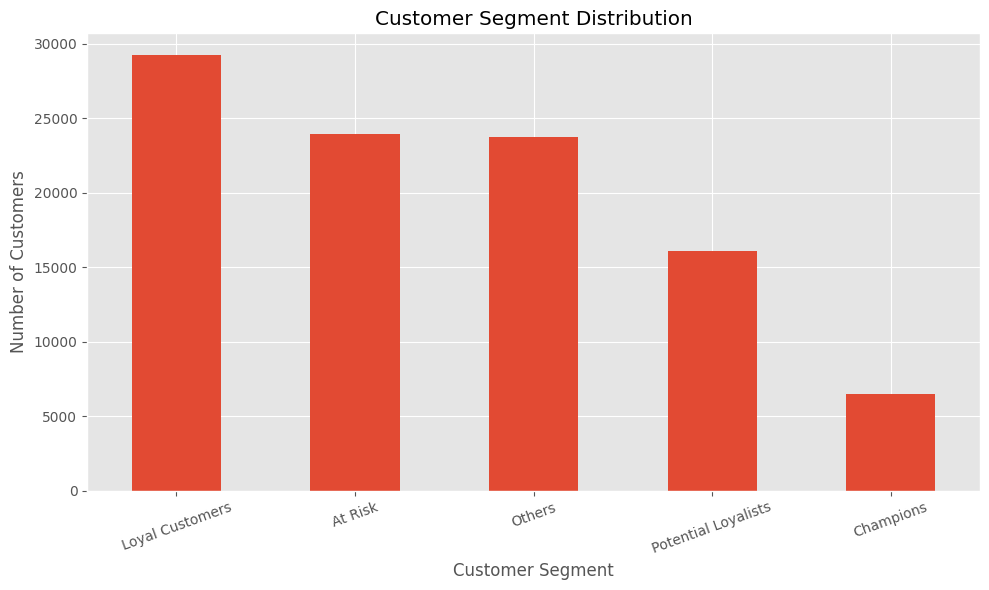

In [24]:
plt.figure(figsize=(10,6))

segment_distribution.plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

Customer segmentation identifies high-value customers, loyal buyers, and customers at risk of churn. These segments enable targeted marketing campaigns and customer retention strategies.

# Revenue by Customer Segment

In [25]:
segment_revenue = (
    rfm_table
    .groupby("Customer Segment")
    .agg(
        Revenue=("Monetary","sum")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

segment_revenue

,Revenue
Customer Segment,
At Risk,3867900.48
Loyal Customers,3844034.57
Others,3738367.73
Potential Loyalists,2618752.43
Champions,1939816.91


<Figure size 1000x600 with 0 Axes>

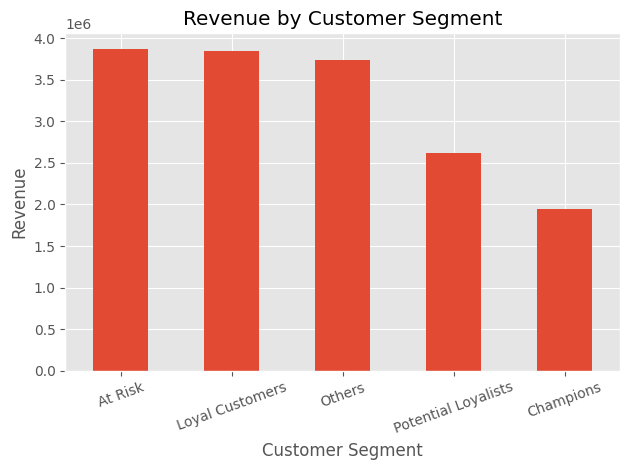

In [26]:
plt.figure(figsize=(10,6))

segment_revenue.plot(
    kind="bar",
    legend=False
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

Revenue analysis across customer segments highlights the financial contribution of each group. High-value segments should receive retention-focused marketing, while lower-value segments may require engagement campaigns.

# Top Customers

In [27]:
top_customers = (
    rfm_table
    .sort_values(
        by="Monetary",
        ascending=False
    )
    .head(10)
)

top_customers

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer Segment
customer_id,,,,,,,,
1617b1357756262bfa56ab541c47bc16,384,1,13664.08,2,1,5,215,Others
ec5b2ba62e574342386871631fafd3fc,95,1,7274.88,5,5,5,555,Champions
c6e2731c5b391845f6800c97401a43a9,612,1,6929.31,1,4,5,145,At Risk
f48d464a0baaea338cb25f816991ab1f,84,1,6922.21,5,5,5,555,Champions
3fd6777bbce08a352fddd04e4a7cc8f6,511,1,6726.66,1,2,5,125,Others
05455dfa7cd02f13d132aa7a6a9729c6,328,1,6081.54,2,1,5,215,Others
df55c14d1476a9a3467f131269c2477f,565,1,4950.34,1,5,5,155,At Risk
e0a2412720e9ea4f26c1ac985f6a7358,98,1,4809.44,5,5,5,555,Champions
24bbf5fd2f2e1b359ee7de94defc4a15,547,1,4764.34,1,1,5,115,Others


# Key Insights

- Customer purchasing behavior varies significantly across the marketplace.
- A relatively small group of customers contributes a large share of total revenue.
- High-value customer segments should be prioritized for retention.
- Customers with low recency and low purchase frequency represent churn risk.
- RFM segmentation provides a data-driven foundation for personalized marketing.

# Business Recommendations

- Develop exclusive loyalty programs for Champions and Loyal Customers.
- Launch personalized offers for Potential Loyalists.
- Re-engage At Risk customers using targeted campaigns and incentives.
- Monitor customer movement between segments on a regular basis.
- Use RFM scores to improve customer lifetime value and marketing ROI.